# 4D-STEM experiment of CsPbBr3

In [1]:
# # ===============================
# # Environment setup (RUN FIRST)
# # ===============================

# import os

# # numba cache 目录（避免 ProgramData 权限问题）
# NUMBA_CACHE = r"C:\Users\19817\.numba_cache"
# os.makedirs(NUMBA_CACHE, exist_ok=True)

# os.environ["NUMBA_CACHE_DIR"] = NUMBA_CACHE
# os.environ["NUMBA_DISABLE_JIT"] = "0"

# # 防止 pylops 强制调用 cupy
# os.environ["CUPY_PYLOPS"] = "0"

# print("NUMBA cache dir:", os.environ["NUMBA_CACHE_DIR"])

In [1]:
# matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

# basic packages
import numpy as np
import cupy as cp
import multiprocessing
import typing
import sys
import os

# # ===== 添加用户site-packages路径（让pixstem能被找到）=====
# sys.path.append(r"C:\Users\19817\AppData\Roaming\Python\Python310\site-packages")

# 4D-STEM packages
import py4DSTEM

# ptychography package
import sys
sys.path.append(r'C:\Users\EMC\Documents\pyptychostem-master')
from STEM4D import *
if 'Data4D' in dir():
    print(1)
    
    # 进一步判断是类还是函数
    import inspect
    if inspect.isclass(Data4D):
        print(2)
    elif inspect.isfunction(Data4D):
        print(3)
    else:
        print(4)
        
else:
    print(5)

# optional pixstem
# try:
#     import pixstem.api as ps
#     print("pixstem loaded (iCOM available)")
# except:
#     print("cannot load pixstem package...")
#     print("iCOM not possible")

# GPU info
print("GPU detected:", cp.cuda.runtime.getDeviceCount())

cupyx.jit.rawkernel is experimental. The interface can change in the future.


cannot load pixstem package...
4D plot not possible
1
2
GPU detected: 1


In [2]:
# ===============================
# Input settings (txt / npy)
# ===============================

from types import SimpleNamespace

# Option 1: "txt" -> use Data4D(parameters.txt)
# Option 2: "npy" -> direct load 4D cube (*.npy)
input_mode = "npy"   # "txt" or "npy"
input_path = r"H:\COF_4D\SI data (88)\data_4D_binned_mask.npy"

# Only used when input_mode == "npy"
step_size_A = 0.3                 # scan step in Angstrom
q_pixel_size_mrad = 1.0           # reciprocal pixel size in mrad
energy_eV_manual = 200e3          # acceleration voltage in eV
semiangle_cutoff_mrad_manual = None  # if None, estimated from BF disk radius


In [3]:
# Load input as Data4D-like object
if input_mode.lower() == "txt":
    parfile = input_path
    data_4D = Data4D(parfile)
    data_4D.estimate_aperture_size()
elif input_mode.lower() == "npy":
    npy_path = input_path
    cube = np.load(npy_path)
    data_4D = SimpleNamespace(
        data_4D=cube,
        step_size=step_size_A,
        path=os.path.dirname(npy_path) + os.sep,
        aperturesize=None,
        aperture_radius=None,
        voltage=energy_eV_manual / 1000.0,
    )
    print("Loaded npy shape:", cube.shape)

else:
    raise ValueError("input_mode must be 'txt' or 'npy'")


Loaded npy shape: (240, 240, 128, 128)


In [ ]:
# 使用 pyxem 直接查看 4D-STEM 数据（替代 stem4d 的 plot_4D）
import pyxem as pxm

pxm_4d = pxm.signals.ElectronDiffraction2D(data_4D.data_4D)
pxm_4d.axes_manager.navigation_axes[0].name = "scan_y"
pxm_4d.axes_manager.navigation_axes[1].name = "scan_x"
pxm_4d.axes_manager.signal_axes[0].name = "ky"
pxm_4d.axes_manager.signal_axes[1].name = "kx"

# 与 plot_4D 类似：导航维度为扫描坐标，信号维度为衍射图
pxm_4d.plot()


In [4]:
# quick sanity check
print("input_mode:", input_mode)
print("data shape:", data_4D.data_4D.shape)
print("data path:", data_4D.path)


input_mode: npy
data shape: (240, 240, 128, 128)
data path: H:\COF_4D\SI data (88)\


In [5]:
# calculate the electron dose, unit = e-/Å2
Ronchi_mean = np.mean(data_4D.data_4D, (0, 1))
events = Ronchi_mean.sum() / data_4D.step_size / data_4D.step_size
print('events =', events)

dose = events * (1 / 3.85) * 0.96
print('electron dose =', dose, 'e-/Å2')


events = 63536.850163966046
electron dose = 15842.954846079843 e-/Å2


In [6]:
#data_4D_float = data_4D.data_4D.astype(np.float16)
#data_4D_float += 0.000001
#data_4D.data_4D=data_4D_float

In [7]:
# Q pixel size (mrad)
if (getattr(data_4D, 'aperturesize', None) is not None) and (getattr(data_4D, 'aperture_radius', None) is not None):
    Q_pixel_size = data_4D.aperturesize / data_4D.aperture_radius * 1000
else:
    Q_pixel_size = q_pixel_size_mrad


In [8]:
Q_pixel_size

1.0

In [9]:
# Make a 4D datacube (new py4DSTEM API)

datacube = py4DSTEM.DataCube(data=data_4D.data_4D)
datacube.calibration.set_R_pixel_size(data_4D.step_size)
datacube.calibration.set_R_pixel_units('A')
datacube.calibration.set_Q_pixel_size(Q_pixel_size)
datacube.calibration.set_Q_pixel_units('mrad')

# backward compatible alias used in some older snippets
dataset = datacube


In [10]:
datacube

DataCube( A 4-dimensional array of shape (240, 240, 128, 128) called 'datacube',
          with dimensions:

              Rx = [0.0,0.3,0.6,...] A
              Ry = [0.0,0.3,0.6,...] A
              Qx = [0.0,1.0,2.0,...] mrad
              Qy = [0.0,1.0,2.0,...] mrad
)

In [11]:
# save a file with just the datacube

filepath_h5 = 'D:/simulation/test291.h5'

py4DSTEM.io.save(
    filepath_h5,
    datacube,
    tree = False,
    mode = 'o'
)

FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = 'D:/simulation/test291.h5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 302)

In [12]:
py4DSTEM.print_h5_tree(filepath_h5)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'D:/simulation/test291.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [13]:
py4DSTEM.io.read(filepath_h5)


AssertionError: specified filepath 'D:/simulation/test291.h5' does not exist

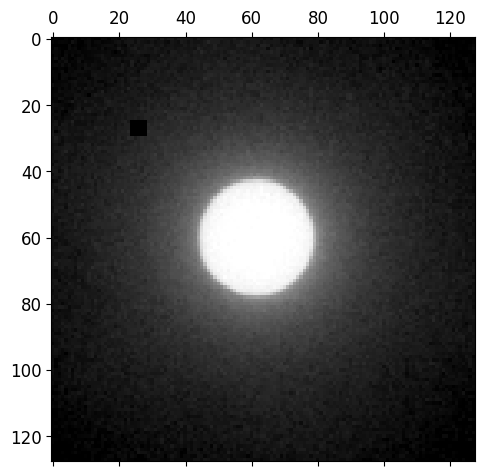

In [14]:
from py4DSTEM.visualize import show
datacube.data.shape
# Calculate the mean diffraction pattern:
# Calculate the mean diffraction pattern over axis=0 and 1 (the probe x and y scan directions)
diff_mean = np.mean(datacube.data,axis=(0,1))

# Plot the mean diffraction pattern
py4DSTEM.visualize.show(diff_mean,
                       scaling='power',
                       power=0.333)

Estimated probe radius = 17.36 pixels


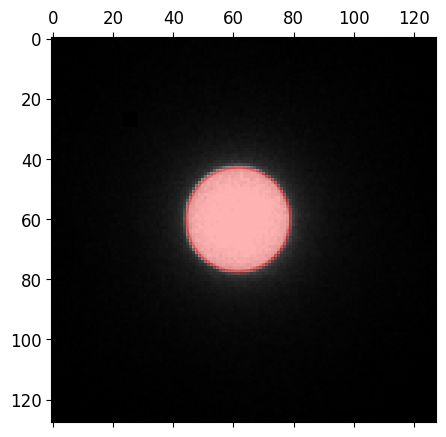

In [15]:
# Estimate the radius of the BF disk, and the center coordinates
probe_semiangle_pixels, qx0, qy0 = py4DSTEM.process.calibration.get_probe_size(diff_mean)

# optional manual override
# qx0, qy0 = 7.5, 7.5

py4DSTEM.visualize.show_circles(diff_mean, (qx0, qy0), probe_semiangle_pixels)
print('Estimated probe radius =', '%.2f' % probe_semiangle_pixels, 'pixels')


In [16]:
#angstrom
defocus_value=0

Best fit rotation forced to 80 degrees.

ormalizing amplitudes: 100%|███████████████████████████████████████| 57600/57600 [00:57<00:00, 995.89probe position/s]

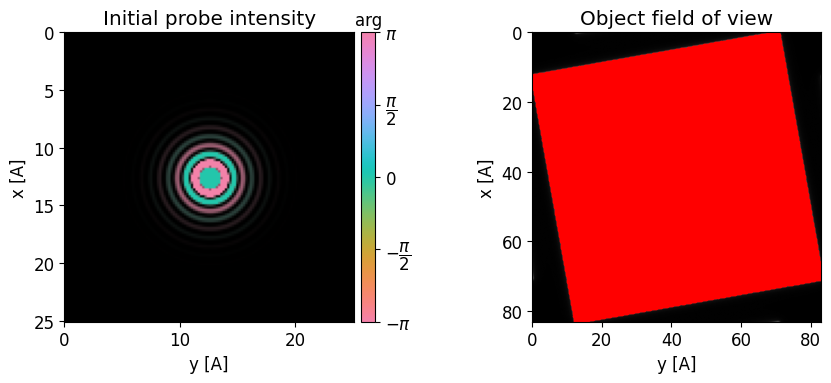

In [19]:
## Single-slice reconstruction (new py4DSTEM API)
if semiangle_cutoff_mrad_manual is None:
    semiangle_cutoff_mrad = probe_semiangle_pixels * Q_pixel_size
else:
    semiangle_cutoff_mrad = semiangle_cutoff_mrad_manual

if hasattr(data_4D, 'voltage') and data_4D.voltage is not None:
    energy_eV = float(data_4D.voltage) * 1000.0 if float(data_4D.voltage) < 1e4 else float(data_4D.voltage)
else:
    energy_eV = energy_eV_manual

ptycho = py4DSTEM.process.phase.SingleslicePtychography(
    datacube=datacube,
    verbose=True,
    energy=energy_eV,
    semiangle_cutoff=semiangle_cutoff_mrad,
    defocus=defocus_value,
    object_padding_px=(0, 0),
    device='gpu',
).preprocess(
    plot_center_of_mass=False,
    plot_rotation=False,
    force_com_rotation=80,
    fit_function='plane',
)


Performing 100 iterations using a complex object type, with the gradient-descent algorithm, with normalization_min: 1 and step_size: 0.5, in batches of max 4096 measurements.

econstructing object and probe: 100%|████████████████████████████████████████████| 100/100 [01:11<00:00,  1.40 iter/s]

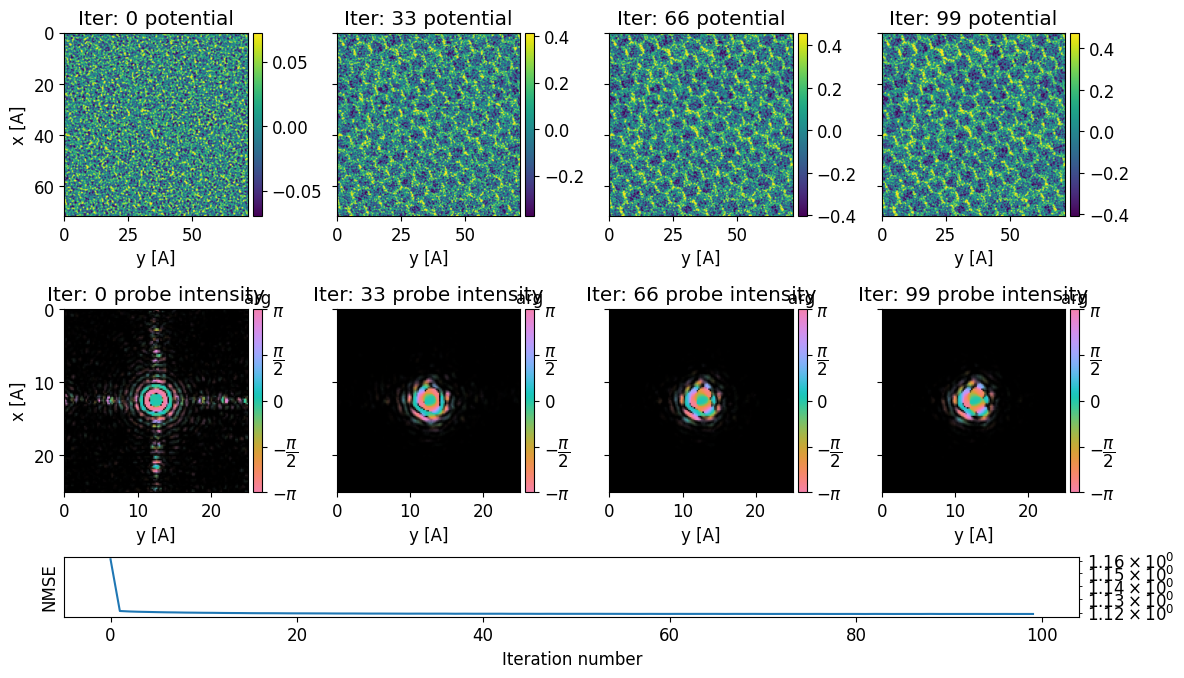

In [20]:
ptycho = ptycho.reconstruct(
    reset=True,
    store_iterations=True,
    num_iter=100,
    pure_phase_object=False,
    normalization_min=1,
    max_batch_size=4096,
    # gaussian_filter_sigma=0.5,
    step_size=0.5,
).visualize(
    cbar=True,
    iterations_grid='auto',
    cmap='viridis',
)


In [ ]:
phase = np.angle(ptycho.object)
from tifffile import tifffile
tifffile.imwrite(data_4D.path+'phase_py4D_256_sslice64'+'.tif', phase.astype('float32'), imagej=True)

In [32]:
data_4D.path

'D:\\EMAT\\MAPbI3_raw\\d29/'

In [33]:
## Multi-slice ptychography
slice_thicknesses = 10
num_slices = 3


C:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\py4DSTEM\process\phase\iterative_base_class.py:537: UserWarning: Best fit rotation forced to 175 degrees.
  warnings.warn(
C:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\py4DSTEM\process\phase\iterative_base_class.py:551: UserWarning: Transpose of intensities forced to False.
  warnings.warn(


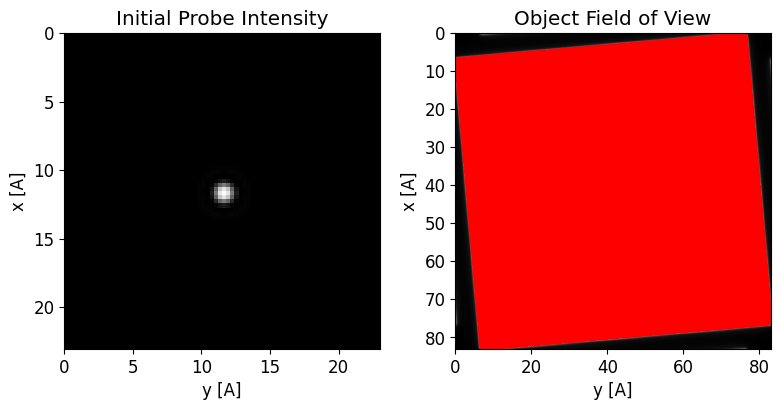

In [34]:
ms_ptycho = py4DSTEM.process.phase.MultislicePtychography(
    datacube=datacube,
    num_slices=num_slices,
    slice_thicknesses=slice_thicknesses,
    verbose=True,
    energy=energy_eV,
    defocus=defocus_value,
    semiangle_cutoff=semiangle_cutoff_mrad,
    object_padding_px=(0, 0),
    device='cpu',
).preprocess(
    plot_center_of_mass=True,
    force_com_transpose=False,
    force_com_rotation=175,
    fit_function='plane',
)


In [1]:
ms_ptycho = ms_ptycho.reconstruct(
    reset=True,
    store_iterations=True,
    num_iter=40,
    pure_phase_object=False,
    normalization_min=1,
    # gaussian_filter_sigma=None,
    step_size=0.5,
    # max_batch_size=64,
).visualize(
    cbar=True,
    iterations_grid='auto',
    cmap='viridis',
)


NameError: name 'ms_ptycho' is not defined

In [ ]:
ms_ptycho.reconstruct?

In [37]:
phase = np.angle(ms_ptycho.object)
from tifffile import tifffile
tifffile.imwrite(data_4D.path+'phase_py4D_256_mslice40'+'.tif', phase.astype('float32'), imagej=True)

In [27]:
import algotom.prep.phase as app
from skimage import restoration
import matplotlib.pyplot as plt
import numpy as np
import cv2

Func = ms_ptycho.object

print(Func.shape)
im = np.angle(Func)


offset = 0.1
#Func_fft = np.fft.fftshift(np.fft.fft2(Func)))
Func_fft = np.fft.fft2(Func)
Phase_Func_fft = np.angle(Func_fft)
Amp_Func_fft = np.abs(Func_fft)

Phase_Func_fft[0][0] += offset

Func_fft_unwrapped = Amp_Func_fft*np.exp(1j*Phase_Func_fft)
Func_unwrapped = np.fft.ifft2(Func_fft_unwrapped)

im_unwrapped_offset = np.angle(Func_unwrapped)
#'''
print(np.min(im_unwrapped_offset))
im_unwrapped_cosine_transform = app.unwrap_phase_based_cosine_transform(im)

x_start = im.shape[1] // 2  # 图像的水平中间位置
width = 10  # 提取2像素宽的区域

# 提取该区域的像素值
region_of_interest1 = im[:, x_start:x_start + width]
region_of_interest2 = im_unwrapped_offset[:, x_start:x_start + width]
region_of_interest3 = im_unwrapped_cosine_transform[:, x_start:x_start + width]

# 计算该区域每一行的平均值，得到line profile
line_profile1 = np.mean(region_of_interest1, axis=1)
line_profile2 = np.mean(region_of_interest2, axis=1)
line_profile3 = np.mean(region_of_interest3, axis=1)

# 绘制line profile
# 绘制line profile并加上label
plt.plot(line_profile1, label='Raw Result')
plt.plot(line_profile2, label='Offset Unwrapped')
plt.plot(line_profile3, label='Cosine Transform Unwrapped')

# 添加图例以显示标签
plt.legend()

# 添加标题和轴标签
plt.xlabel('Pixels (vertical direction)')
plt.ylabel('Averaged Intensity')
plt.title('Line Profiles for Different Images')

# 显示图像
plt.show()

plt.xlabel('pixels (vertical direction)')
plt.ylabel('averaged intensity')
plt.title('Line Profile of 2-pixel-wide vertical strip')
plt.show()

plt.figure(figsize=(14, 6))
plt.subplot(131)
plt.title('Raw Result')
plt.imshow(im, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.subplot(132)
plt.title('Offset Unwrapped, offset='+str(offset))
plt.imshow(im_unwrapped_offset, cmap='gray')
plt.xticks([])
plt.yticks([])

plt.subplot(133)
plt.title('Cosine Transform Unwrapped')
plt.imshow(im_unwrapped_cosine_transform, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.show()

cv2.imwrite(folder_write+file+'_offset_'+str(offset)+'.tif', im_unwrapped_offset.astype(np.float32))  

(6, 274, 274)
-1.5955805288082574


ValueError: too many values to unpack (expected 2)

In [28]:
import algotom.prep.phase as app
from skimage import restoration
import matplotlib.pyplot as plt
import numpy as np
import cv2

Func = ms_ptycho.object

print(Func.shape)
im = np.angle(Func)



offset = 0.7
#Func_fft = np.fft.fftshift(np.fft.fft2(Func)))
Func_fft = np.fft.fft2(Func)
Phase_Func_fft = np.angle(Func_fft)
Amp_Func_fft = np.abs(Func_fft)

Phase_Func_fft[0][0] += offset

Func_fft_unwrapped = Amp_Func_fft*np.exp(1j*Phase_Func_fft)
Func_unwrapped = np.fft.ifft2(Func_fft_unwrapped)

im_unwrapped_offset = np.angle(Func_unwrapped)
#'''

im_unwrapped_cosine_transform = app.unwrap_phase_based_cosine_transform(im)      #DOI:10.1364/JOSAA.11.000107
im_unwrapped_fft = app.unwrap_phase_based_fft(im)                                #DOI:10.1109/36.297989
im_unwrapped_reliability_sorting = restoration.unwrap_phase(im)                  #DOI:10.1364/AO.41.007437
im_unwrapped_iterative_fft = app.unwrap_phase_iterative_fft(im, iteration=50)    #DOI:10.1364/AO.56.007079


plt.figure(figsize=(14, 6))
plt.subplot(231)
plt.title('Raw Result')
plt.imshow(im, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.subplot(232)
plt.title('Offset Unwrapped, offset='+str(offset))
plt.imshow(im_unwrapped_offset, cmap='gray')
plt.xticks([])
plt.yticks([])
#plt.clim([1,2])
plt.subplot(233)
plt.title('Cosine Transform Unwrapped')
plt.imshow(im_unwrapped_cosine_transform, cmap='gray')
plt.xticks([])
plt.yticks([])
#plt.show()
#'''

plt.subplot(234)
plt.title('FFT Unwrapped')
plt.imshow(im_unwrapped_fft, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.subplot(235)
plt.title('Reliability Sorting Unwrapped')
plt.imshow(im_unwrapped_reliability_sorting, cmap='gray')
plt.xticks([])
plt.yticks([])
#plt.clim([1,2])
plt.subplot(236)
plt.title('Iterative FFT Unwrapped')
plt.imshow(im_unwrapped_iterative_fft, cmap='gray')
plt.xticks([])
plt.yticks([])
plt.show()
#'''
cv2.imwrite(folder_write+file+'_im_'+'.tif', im.astype(np.float32))  
cv2.imwrite(folder_write+file+'_im_unwrapped_offset_'+str(offset)+'.tif', im_unwrapped_offset.astype(np.float32))  
cv2.imwrite(folder_write+file+'_cosine_transform_'+'.tif', im_unwrapped_cosine_transform.astype(np.float32))  
cv2.imwrite(folder_write+file+'_fft_'+'.tif', im_unwrapped_fft.astype(np.float32))  
cv2.imwrite(folder_write+file+'_reliability_sorting_'+'.tif', im_unwrapped_reliability_sorting.astype(np.float32))  
cv2.imwrite(folder_write+file+'_iterative_fft_'+'.tif', im_unwrapped_iterative_fft.astype(np.float32))  

(6, 274, 274)


ValueError: too many values to unpack (expected 2)

In [25]:
from tifffile import tifffile
tifffile.imsave(data_4D.path+'phase'+'.tif', phase.astype('float32'), imagej=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27448\4058414217.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(data_4D.path+'phase'+'.tif', phase.astype('float32'), imagej=True)


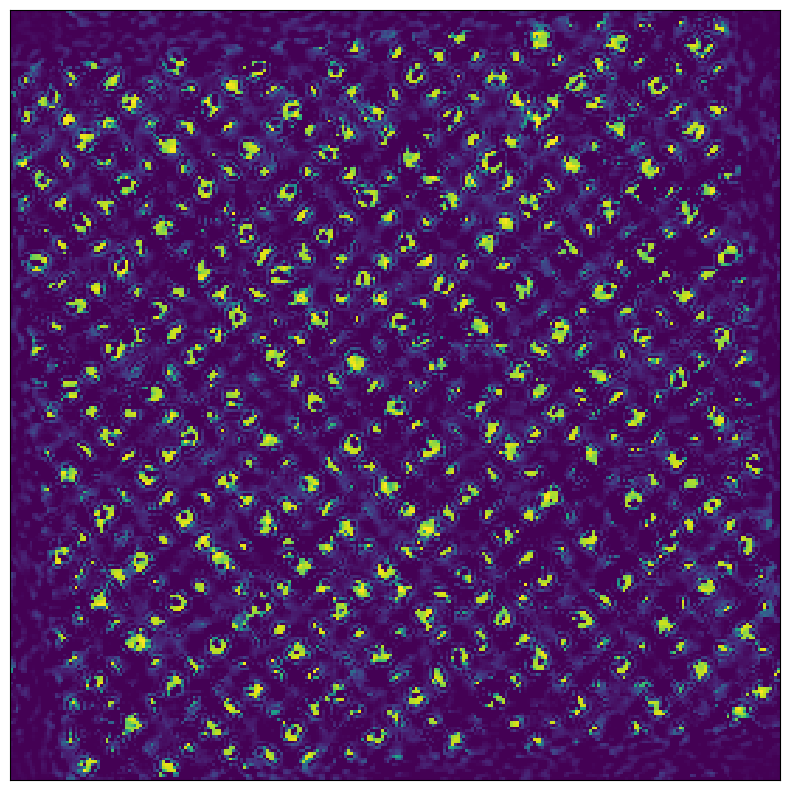

In [38]:
py4DSTEM.show(
    np.angle(ms_ptycho.object).sum(0)+np.angle(ms_ptycho.object).sum(0)+np.angle(ms_ptycho.object).sum(0),
    cmap='viridis',
    vmin=0.333,
    vmax=0.999,
    ticks=False,
    figsize=(10,10),
)